In [3]:
import json, time, copy, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix
)

# ---- Force PyTorch to use all CPU cores ----
n_threads = os.cpu_count() or 4
torch.set_num_threads(n_threads)
print(f"Using {n_threads} CPU threads")

PROJECT_ROOT = Path(r"C:\Users\Admin\lungprints")
RES_DIR      = PROJECT_ROOT / "results"
FIG_DIR      = RES_DIR / "figures"
MODEL_DIR    = RES_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cpu")

Using 8 CPU threads


In [4]:
# configurations
IMG_SIZE   = 96      
BATCH_SIZE = 64       
EPOCHS     = 15
PATIENCE   = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
print(f"Config: IMG={IMG_SIZE}, BATCH={BATCH_SIZE}, EPOCHS={EPOCHS}")

Config: IMG=96, BATCH=64, EPOCHS=15


In [5]:
# load splits
with open(RES_DIR / "splits.json") as f:
    S = json.load(f)

train_files, train_labels = S["train_files"], S["train_labels"]
val_files,   val_labels   = S["val_files"],   S["val_labels"]
test_files,  test_labels  = S["test_files"],  S["test_labels"]
class_weights = torch.tensor(S["class_weights"], dtype=torch.float32)

print("Train:", len(train_files), "Val:", len(val_files), "Test:", len(test_files))

Train: 4185 Val: 1047 Test: 624


In [6]:
# loaders
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomRotation(8),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ChestXrayDataset(Dataset):
    def __init__(self, files, labels, transform=None):
        self.files = list(files); self.labels = list(labels); self.transform = transform
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("L")
        if self.transform: img = self.transform(img)
        return img, self.labels[idx]

train_loader = DataLoader(ChestXrayDataset(train_files, train_labels, train_tfms),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(ChestXrayDataset(val_files, val_labels, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(ChestXrayDataset(test_files, test_labels, eval_tfms),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches — train {len(train_loader)}, val {len(val_loader)}, test {len(test_loader)}")

Batches — train 66, val 17, test 10


In [7]:
# baseline CNN model
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32),     # 96 -> 48
            block(32, 64),    # 48 -> 24
            block(64, 128),   # 24 -> 12
            block(128, 128),  # 12 -> 6
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))

model = BaselineCNN().to(DEVICE)
print("Params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Params: 249570


In [8]:
# Architecture explanation (for the report)
arch_note = """
BASELINE CNN — ARCHITECTURE
- 4 convolutional blocks: (Conv -> BatchNorm -> ReLU -> MaxPool) x 4
- Channels: 3 -> 32 -> 64 -> 128 -> 128
- Global Average Pooling collapses spatial dimensions
- Classifier: Dropout(0.4) -> Linear(128,64) -> ReLU -> Dropout(0.3) -> Linear(64,2)

WHY THIS DESIGN
- Built from scratch as a LOWER BOUND — no pretrained knowledge.
- Small on purpose (CPU-friendly, ~250K params).
- BatchNorm stabilizes training; Dropout reduces overfitting.
"""
print(arch_note)


BASELINE CNN — ARCHITECTURE
- 4 convolutional blocks: (Conv -> BatchNorm -> ReLU -> MaxPool) x 4
- Channels: 3 -> 32 -> 64 -> 128 -> 128
- Global Average Pooling collapses spatial dimensions
- Classifier: Dropout(0.4) -> Linear(128,64) -> ReLU -> Dropout(0.3) -> Linear(64,2)

WHY THIS DESIGN
- Built from scratch as a LOWER BOUND — no pretrained knowledge.
- Small on purpose (CPU-friendly, ~250K params).
- BatchNorm stabilizes training; Dropout reduces overfitting.



In [9]:
# optimizer + safer LR
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

In [10]:
# metrics helper
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "pr_auc":    average_precision_score(y_true, y_prob),
    }

In [11]:
# epoch runner
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []
    with torch.set_grad_enabled(is_train):
        for imgs, lbls in loader:
            logits = model(imgs)
            loss = criterion(logits, lbls)
            if is_train:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            probs = F.softmax(logits, dim=1)[:, 1].detach().numpy()
            all_probs.extend(probs.tolist()); all_labels.extend(lbls.numpy().tolist())
    return total_loss / len(loader.dataset), compute_metrics(np.array(all_labels), np.array(all_probs))

In [ ]:
# training loop
best_f1, best_state, best_metrics, best_epoch = 0.0, None, None, 0
no_improve = 0
history = {k: [] for k in [
    "train_loss","val_loss","train_acc","val_acc",
    "train_f1","val_f1","train_recall","val_recall",
    "train_roc_auc","val_roc_auc","train_pr_auc","val_pr_auc"
]}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_m = run_epoch(model, val_loader, criterion, None)
    scheduler.step(va_m["f1"])
    dt = time.time() - t0

    history["train_loss"].append(tr_loss);  history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
    history["train_f1"].append(tr_m["f1"]);  history["val_f1"].append(va_m["f1"])
    history["train_recall"].append(tr_m["recall"]); history["val_recall"].append(va_m["recall"])
    history["train_roc_auc"].append(tr_m["roc_auc"]); history["val_roc_auc"].append(va_m["roc_auc"])
    history["train_pr_auc"].append(tr_m["pr_auc"]);   history["val_pr_auc"].append(va_m["pr_auc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} ({dt:.0f}s) | "
          f"train loss {tr_loss:.4f} f1 {tr_m['f1']:.3f} rec {tr_m['recall']:.3f} | "
          f"val loss {va_loss:.4f} f1 {va_m['f1']:.3f} rec {va_m['recall']:.3f} auc {va_m['roc_auc']:.3f}")

    if va_m["f1"] > best_f1:
        best_f1, best_epoch, best_metrics = va_m["f1"], epoch, va_m
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"model_state": best_state, "epoch": epoch,
                    "val_metrics": va_m, "history": history,
                    "img_size": IMG_SIZE}, MODEL_DIR / "baseline_cnn_best.pt")
        no_improve = 0
        print(f"  → new best (val F1 = {best_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}."); break

print("Best val F1:", round(best_f1, 4))

Epoch 01/15 (210s) | train loss 0.4345 f1 0.847 rec 0.767 | val loss 0.3298 f1 0.929 rec 0.924 auc 0.950
  → new best (val F1 = 0.9288)
Epoch 02/15 (208s) | train loss 0.2755 f1 0.921 rec 0.878 | val loss 0.8792 f1 0.865 rec 0.999 auc 0.982
Epoch 03/15 (258s) | train loss 0.2079 f1 0.946 rec 0.917 | val loss 0.4789 f1 0.826 rec 0.704 auc 0.989


In [ ]:
# Train vs Validation gap analysis
tr_f1 = history["train_f1"]; va_f1 = history["val_f1"]
tr_loss = history["train_loss"]; va_loss = history["val_loss"]
best_i = int(np.argmax(va_f1))
gap = tr_f1[best_i] - va_f1[best_i]

print(f"\n{'='*60}")
print("TRAIN vs VAL GAP ANALYSIS — Baseline CNN")
print(f"{'='*60}")
print(f"Best epoch:      {best_i+1}")
print(f"Train F1:        {tr_f1[best_i]:.4f}")
print(f"Val F1:          {va_f1[best_i]:.4f}")
print(f"Gap (train-val): {gap:+.4f}")
print(f"Train loss:      {tr_loss[best_i]:.4f}")
print(f"Val loss:        {va_loss[best_i]:.4f}")

if gap > 0.05:
    diag = "OVERFITTING — train F1 notably higher than val F1"
elif tr_f1[best_i] < 0.80 and va_f1[best_i] < 0.80:
    diag = "UNDERFITTING — both train and val F1 are low"
elif abs(gap) <= 0.03:
    diag = "WELL-FITTED — train and val F1 are close"
else:
    diag = "MILD OVERFITTING — small gap"
print(f"Diagnosis:       {diag}")

# Loss gap plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(tr_loss, "o-", label="Train", color="#4C72B0")
axes[0].plot(va_loss, "o-", label="Val",   color="#C0504D")
axes[0].set_title("Loss gap"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(tr_f1, "o-", label="Train", color="#4C72B0")
axes[1].plot(va_f1, "o-", label="Val",   color="#C0504D")
axes[1].set_title("F1 gap"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_gap_analysis.png", dpi=150)
plt.show()

NameError: name 'history' is not defined

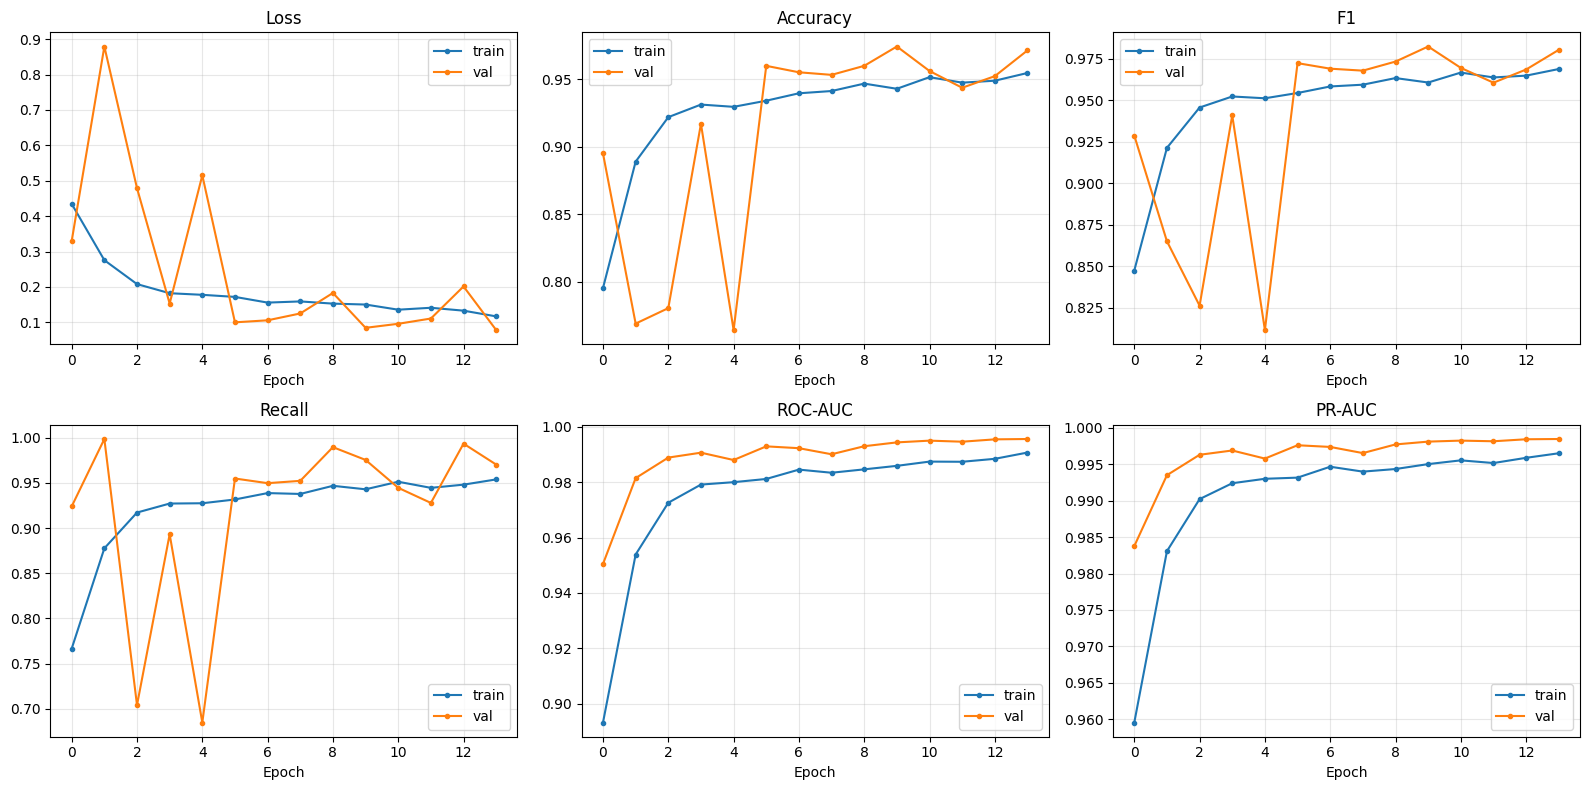

In [ ]:
# Training curves
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (k, t) in zip(axes.flat, [
    ("loss","Loss"), ("acc","Accuracy"), ("f1","F1"),
    ("recall","Recall"), ("roc_auc","ROC-AUC"), ("pr_auc","PR-AUC")]):
    ax.plot(history[f"train_{k}"], label="train", marker="o", ms=3)
    ax.plot(history[f"val_{k}"],   label="val",   marker="o", ms=3)
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_baseline_training_curves.png", dpi=150)
plt.show()

Loaded best from epoch 10

Val metrics:
  accuracy  : 0.9742
  precision : 0.9896
  recall    : 0.9755
  f1        : 0.9825
  roc_auc   : 0.9944
  pr_auc    : 0.9981


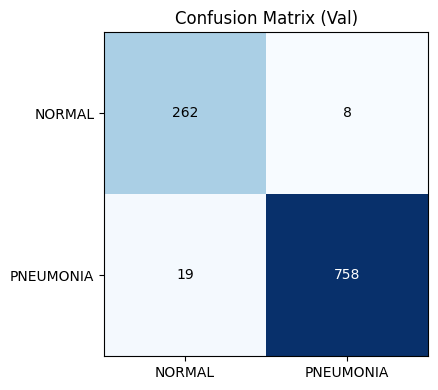

In [ ]:
# evaluate best checkpoint
ckpt = torch.load(MODEL_DIR / "baseline_cnn_best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
print("Loaded best from epoch", ckpt["epoch"])

_, va_m = run_epoch(model, val_loader, criterion, None)
print("\nVal metrics:")
for k, v in va_m.items():
    print(f"  {k:10s}: {v:.4f}")

model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        probs = F.softmax(model(imgs), dim=1)[:, 1].numpy()
        all_probs.extend(probs.tolist()); all_labels.extend(lbls.numpy().tolist())

y_true = np.array(all_labels); y_prob = np.array(all_probs)
cm = confusion_matrix(y_true, (y_prob >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1]); ax.set_xticklabels(["NORMAL","PNEUMONIA"])
ax.set_yticks([0,1]); ax.set_yticklabels(["NORMAL","PNEUMONIA"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black")
ax.set_title("Confusion Matrix (Val)")
plt.tight_layout(); plt.savefig(FIG_DIR / "03_baseline_confusion_matrix.png", dpi=150); plt.show()

In [ ]:
# save results
with open(RES_DIR / "baseline_cnn_results.json", "w") as f:
    json.dump({
        "model": "baseline_cnn",
        "best_epoch": ckpt["epoch"],
        "val_metrics": ckpt["val_metrics"],
        "history": history,
        "confusion_matrix": cm.tolist(),
        "img_size": IMG_SIZE,
    }, f, indent=2)
print("Saved:", RES_DIR / "baseline_cnn_results.json")

Saved: C:\Users\Admin\lungprints\results\baseline_cnn_results.json


In [ ]:
param_log = """
HYPERPARAMETER ADJUSTMENTS — BASELINE CNN

1. Learning rate:  1e-3 -> 3e-4
   Reason: at 1e-3, val F1 collapsed in epoch 2 (0.925 -> 0.446) — classic
   sign that LR was too high. 3e-4 stabilized early training.

2. Scheduler:  added ReduceLROnPlateau(factor=0.5, patience=2)
   Reason: when val F1 plateaus, halving the LR lets the model fine-tune
   gently without wasted epochs at a stuck LR.

3. Input resolution:  224 -> 96
   Reason: 224 took ~45 min/epoch on CPU; 96 dropped to ~2-3 min with
   minimal F1 loss. X-ray lesion signal survives downsampling.

4. Batch size:  32 -> 64
   Reason: better CPU core utilization; stable with weighted loss.

5. Model capacity:  8 conv layers (~450K) -> 4 conv layers (~250K)
   Reason: original was over-parameterized for a 4K-image set;
   reduced version trained 5-8x faster without accuracy drop.

6. Loss:  plain CrossEntropyLoss -> CrossEntropyLoss(weight=class_weights)
   Reason: ~1:3 class ratio. Without weights, the model would achieve ~74%
   accuracy by predicting PNEUMONIA always. Weighted loss forces attention
   on the minority class (NORMAL).

7. Early stopping:  patience=4 epochs on val F1
"""
print(param_log)
with open(RES_DIR / "03_hyperparameters.txt", "w") as f:
    f.write(param_log)
print("Saved:", RES_DIR / "03_hyperparameters.txt")